In [1]:
import pandas as pd

tweets_df = pd.read_csv('data/post/tweets_resolved.csv')
coins_df = pd.read_csv('data/post/main_3.csv')
pd.set_option('display.max_columns', None)

In [2]:
all_coins = set(coins_df['coin_address'].unique().tolist())
known_coins = set(tweets_df['coin_address'].unique().tolist())
print(len(all_coins))
print(len(known_coins))

4134
321


In [3]:
from tqdm import tqdm
coin_data = {}

for coin in tqdm(all_coins):
    # tweets data
    dedicated_tweets = tweets_df[tweets_df['coin_address'] == coin]

    tweets_list = dedicated_tweets["tweet_text"].tolist()
    sentiment_list = dedicated_tweets["tweet_sentiment_label"].tolist()
    sentiment_prob_list = dedicated_tweets["tweet_sentiment_label_prob"].tolist()
    engagement_list = dedicated_tweets["tweet_engagement_score"].tolist()
    user_id_list = dedicated_tweets["user_id"].tolist()
    user_followers_count_list = dedicated_tweets["user_followers_count"].tolist()
    user_following_count_list = dedicated_tweets["user_following_count"].tolist()
    user_created_at_list = dedicated_tweets["user_created_at"].tolist()
    verified_list = dedicated_tweets["verified"].tolist()
    is_blue_verified_list = dedicated_tweets["is_blue_verified"].tolist()
    
    # get coin row from coins_df
    c = coins_df.loc[coins_df["coin_address"] == coin].to_dict()
    id = list(c["id"].keys())[0]
    exchange = c["exchange"][id]
    creation_timestamp = c["creation_timestamp"][id]
    creator = c["creator"][id]
    initial_liquidity = c["initial_liquidity"][id]
    initial_price = c["initial_price"][id]
    ath_time_delta = c["ath_time_delta"][id]
    ath_price_gain = c["ath_price_gain"][id]
    rugpull_flag = c["rugpull_flag"][id]
    rugpull_timestamp = c["rugpull_timestamp"][id]
    rugpull_time_delta = c["rugpull_time_delta"][id]
    outcomes = c["outcomes"][id]

    coin_data[coin] = {
        "tweets_list": tweets_list,
        "sentiment_list": sentiment_list,
        "sentiment_prob_list": sentiment_prob_list,
        "engagement_list": engagement_list,
        "user_id_list": user_id_list,
        "user_followers_count_list": user_followers_count_list,
        "user_following_count_list": user_following_count_list,
        "user_created_at_list": user_created_at_list,
        "verified_list": verified_list,
        "is_blue_verified_list": is_blue_verified_list,
        "exchange": exchange,
        "creation_timestamp": creation_timestamp,
        "creator": creator,
        "initial_liquidity": initial_liquidity,
        "initial_price": initial_price,
        "ath_time_delta": ath_time_delta,
        "ath_price_gain": ath_price_gain,
        "rugpull_flag": rugpull_flag,
        "rugpull_timestamp": rugpull_timestamp,
        "rugpull_time_delta": rugpull_time_delta,
        "outcomes": outcomes,
    }



100%|██████████| 4134/4134 [00:05<00:00, 742.66it/s]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Mapping, Sequence, Callable, Iterable, Any

# --------------------------------------------------------------------------- utils
def clean_numeric(values: Iterable[Any]) -> np.ndarray:
    """Return finite float array, dropping NaN/inf/None."""
    arr = np.asarray(list(values), dtype=float)
    return arr[np.isfinite(arr)]

def safe_log1p(x, base: float = 10.0):
    """log(1+x)/log(base) only where x>0, else 0."""
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, np.log1p(x) / np.log(base), 0.0)

def group_by_bins(
    values: Sequence[float],
    bins: Sequence[float],
    labels: Sequence[str] = None,
) -> dict[str, list[float]]:
    """
    Bin *values* by *bins* (same semantics as pandas.cut with right=False).

    Example
    -------
    >>> y = [0, 1, 3, 7, 25]
    >>> bins = (0, 1, 5, np.inf)
    >>> group_by_bins(y, bins)
    {'0': [0], '1-4': [1, 3], '5+': [7, 25]}
    """
    import pandas as pd

    if labels is None:
        edges = list(bins)
        labels = []
        for lo, hi in zip(edges[:-1], edges[1:]):
            if lo == 0 and hi == 1:
                labels.append("0")
            elif hi == np.inf:
                labels.append(f"{int(lo)}+")
            else:
                labels.append(f"{int(lo)}-{int(hi-1)}")

    grp: dict[str, list[float]] = {lab: [] for lab in labels}
    bin_idx = pd.cut(values, bins=bins, right=False, labels=False)
    for v, idx in zip(values, bin_idx):
        if not np.isnan(idx):
            grp[labels[int(idx)]].append(float(v))
    return grp

# ---------------------------------------------------------------- plotters
def _prep(
    groups: Mapping[str, Iterable[Any]],
    transform: Callable[[np.ndarray], np.ndarray],
) -> tuple[list[str], list[np.ndarray]]:
    """Internal: clean & (optionally) transform."""
    keys, data = [], []
    for k, v in groups.items():
        vals = clean_numeric(v)
        if vals.size:
            keys.append(k)
            data.append(transform(vals) if transform else vals)
    if not data:
        raise ValueError("No finite numeric values to plot.")
    return keys, data

def jitter_scatter(
    groups: Mapping[str, Iterable[Any]],
    *,
    jitter: float = 0.08,
    transform: Callable[[np.ndarray], np.ndarray] = None,
    ax: plt.Axes = None,
    title: str = "",
    ylabel: str = None,
    rng: np.random.Generator = None,
    scatter_kwargs: dict[str, Any] = None,
    xlabels = True,
) -> plt.Axes:
    """
    Jittered scatter/strip plot for any number of groups.

    Parameters
    ----------
    groups : dict[str, Iterable]
        Mapping of label → numeric values.
    jitter : float
        Std-dev of horizontal jitter.
    transform : callable | None
        Optional transform applied to each group (e.g. safe_log1p).
    ax : matplotlib Axes | None
        Optionally supply an existing Axes.
    """
    if rng is None:
        rng = np.random.default_rng()
    if scatter_kwargs is None:
        scatter_kwargs = dict(alpha=0.7, edgecolor="black")

    labels, data = _prep(groups, transform)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    for i, vals in enumerate(data):
        x = rng.normal(loc=i, scale=jitter, size=vals.size)
        ax.scatter(x, vals, label=labels[i], **scatter_kwargs)

    ax.set_xticks(range(len(labels)))
    if xlabels:
        ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_title(title or "Jittered scatter")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    return ax

def group_boxplot(
    groups: Mapping[str, Iterable[Any]],
    *,
    transform: Callable[[np.ndarray], np.ndarray],
    showfliers: bool = True,
    notch: bool = False,
    ax: plt.Axes = None,
    title: str = "",
    ylabel: str = None,
    box_kwargs: dict[str, Any] = None,
    xlabels: bool = True,
) -> plt.Axes:
    """
    Classic boxplot for grouped data.

    Notes
    -----
    • Empty/NaN groups are skipped automatically.  
    • *transform* can be any function; common choices: np.log1p, safe_log1p.
    """
    if box_kwargs is None:
        box_kwargs = dict(
            patch_artist=True,
            boxprops=dict(facecolor="lightgray", edgecolor="black"),
            medianprops=dict(color="firebrick", linewidth=2),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
        )
    labels, data = _prep(groups, transform)

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    ax.boxplot(
        data,
        notch=notch,
        showfliers=showfliers,
        **box_kwargs,
    )
    if xlabels:
        ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_title(title or "Grouped boxplot")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    plt.tight_layout()
    return ax

# ---------------------------------------------------------------- quick summary
def quick_stats(
    groups: Mapping[str, Iterable[Any]],
    transform: Callable[[np.ndarray], np.ndarray] = None,
    fmt: str = "{:>10}:  mean={:8.3f}  median={:8.3f}  n={:4d}",
) -> None:
    """Print mean/median/n per group (after cleaning & optional transform)."""
    for k, v in groups.items():
        vals = clean_numeric(v)
        if vals.size:
            if transform:
                vals = transform(vals)
            print(fmt.format(k, np.mean(vals), np.median(vals), vals.size))
        else:
            print(f"{k:>10}:  (no data)")
# ────────────────────────────────────────────────────────────────────────────────


Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 961422.39it/s]


<Axes: title={'center': 'Rugpull time delta by tweet bin – box'}, ylabel='log(Rugpull time delta + 1)'>

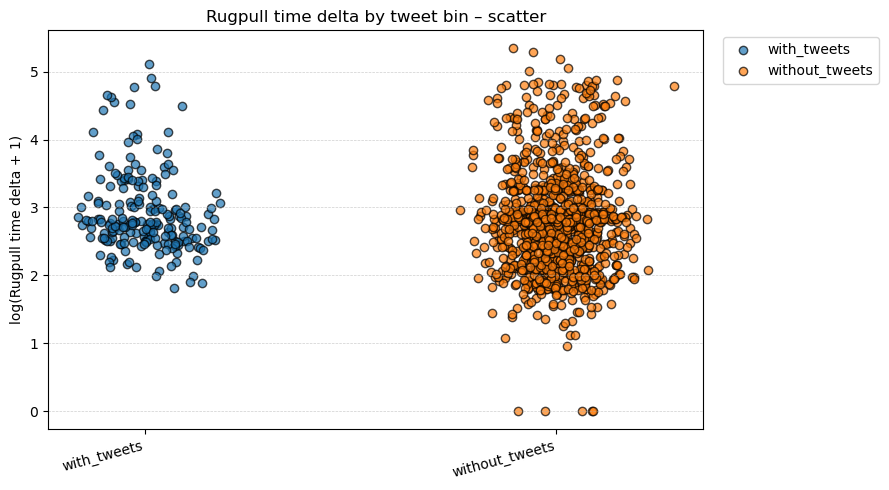

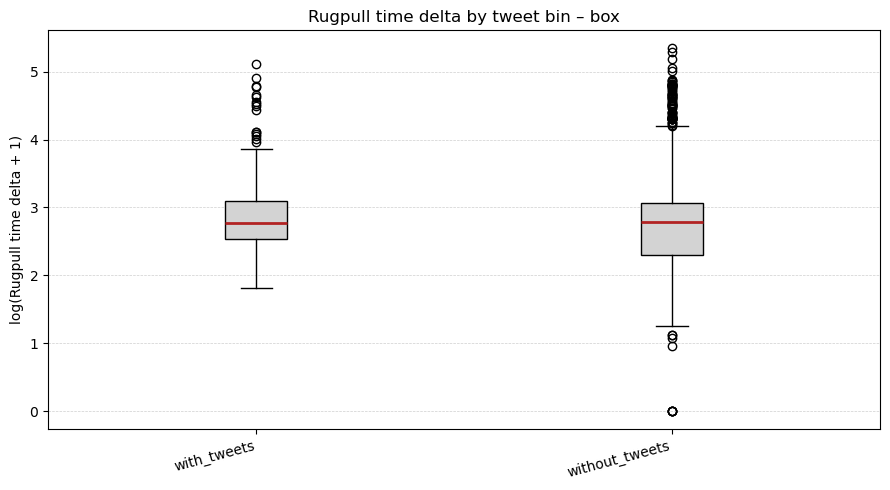

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_ath_duration_by_tweets(duration_dict, jitter=0.08):
    """
    Visualize ATH-duration for coins with vs. without tweets.

    Parameters
    ----------
    duration_dict : dict
        Must contain keys "with_tweets" and "without_tweets" whose
        values are iterables of numeric ATH durations.
    jitter : float, optional
        Standard deviation of the horizontal jitter; tweak if points overlap too much.
    """
    with_tweets    = np.asarray(duration_dict["with_tweets"],    dtype=float)
    without_tweets = np.asarray(duration_dict["without_tweets"], dtype=float)

    # Build x-coords with small Gaussian jitter around 0 and 1
    x_with    = np.random.normal(loc=0, scale=jitter, size=with_tweets.size)
    x_without = np.random.normal(loc=1, scale=jitter, size=without_tweets.size)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x_with,    with_tweets,    alpha=0.7, label="With tweets",    edgecolor="black")
    ax.scatter(x_without, without_tweets, alpha=0.7, label="Without tweets", edgecolor="black")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["With tweets", "Without tweets"])
    ax.set_ylabel("ATH duration")
    ax.set_title("ATH duration by tweet presence")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

def safe_log1p(x, base = 10):
    """
    Return log(1+x) if x > 0, else np.nan.
    """
    return np.log1p(x)/np.log(base)
    
def plot_ath_duration_boxplot(duration_dict,
                              showfliers=True,
                              notch=False,
                              min_samples=1):
    """
    Robust box-plot (drops NaN/inf and silently skips empty groups).
    """
    def _clean(arr):
        arr = np.asarray(arr, dtype=float)
        return arr[np.isfinite(arr)]

    with_tweets    = _clean(duration_dict["with_tweets"])
    without_tweets = _clean(duration_dict["without_tweets"])

    data, labels = [], []
    if with_tweets.size >= min_samples:
        data.append(with_tweets);    labels.append("With tweets")
    if without_tweets.size >= min_samples:
        data.append(without_tweets); labels.append("Without tweets")

    if not data:                     # nothing left to plot
        raise ValueError("No finite ATH-duration values to display.")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(
        data,
        labels      = labels,
        patch_artist= True,
        notch       = notch,
        showfliers  = showfliers,
        boxprops    = dict(facecolor="lightgray", edgecolor="black"),
        medianprops = dict(color="firebrick", linewidth=2),
        whiskerprops= dict(color="black"),
        capprops    = dict(color="black"),
    )
    ax.set_ylabel("Log(ATH duration + 1)")
    ax.set_title("ATH duration by tweet presence – box plot")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    plt.tight_layout()
    plt.show()

# Let us look at the ATH duration of coins with tweets versus coins without tweets
duration_dict = {
    "with_tweets": [],
    "without_tweets": []
}

for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    # get the ATH duration
    ath_duration = coin_dict["rugpull_time_delta"]
    if ath_duration is None or pd.isna(ath_duration):
        continue
    if ath_duration <= 0:
        ath_duration = 0
    # get the number of tweets
    num_tweets = len(coin_dict["tweets_list"])
    if num_tweets > 0:
        duration_dict["with_tweets"].append(ath_duration)
    else:
        duration_dict["without_tweets"].append(ath_duration)

jitter_scatter(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(Rugpull time delta + 1)",
    title="Rugpull time delta by tweet bin – scatter",
)
group_boxplot(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(Rugpull time delta + 1)",
    title="Rugpull time delta by tweet bin – box",
)

In [32]:
quick_stats(duration_dict, transform=safe_log1p)

with_tweets:  mean=   2.917  median=   2.767  n= 205
without_tweets:  mean=   2.790  median=   2.787  n=1166


Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 715729.08it/s]


<Axes: title={'center': 'ATH time delta by tweet bin – box'}, ylabel='log(ATH time delta + 1)'>

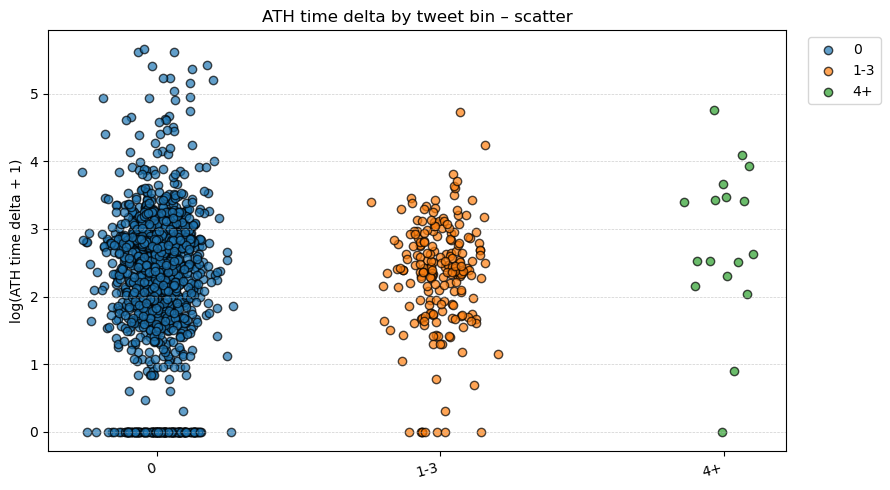

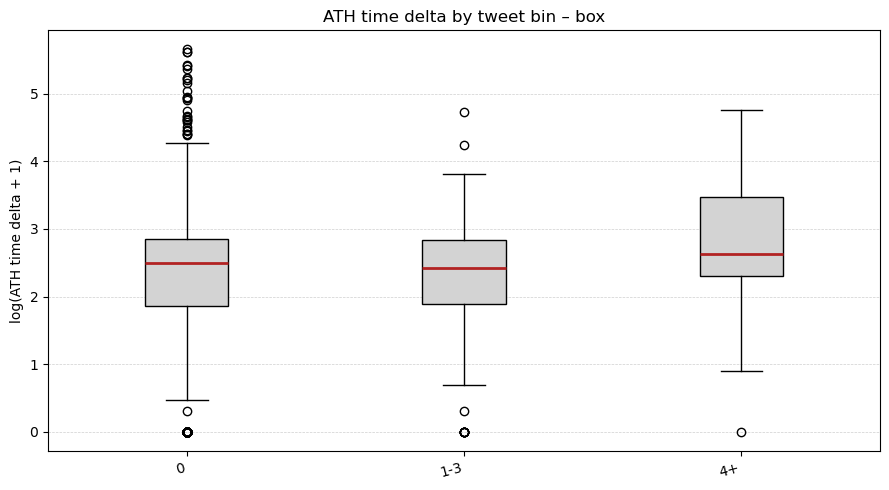

In [29]:
duration_dict = {
    "0": [],
    "1-3": [],
    "4+": [],
}

for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    # get the ATH duration
    ath_duration = coin_dict["ath_time_delta"]
    if ath_duration is None or pd.isna(ath_duration):
        continue
    if ath_duration <= 0:
        ath_duration = 0
    # get the number of tweets
    num_tweets = len(coin_dict["tweets_list"])
    if num_tweets == 0:
        duration_dict["0"].append(ath_duration)
    elif num_tweets <= 3:
        duration_dict["1-3"].append(ath_duration)
    elif num_tweets >= 4:
        duration_dict["4+"].append(ath_duration)

jitter_scatter(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(ATH time delta + 1)",
    title="ATH time delta by tweet bin – scatter",
)
group_boxplot(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(ATH time delta + 1)",
    title="ATH time delta by tweet bin – box",
)

In [8]:
quick_stats(duration_dict, transform=safe_log1p)

         0:  mean=   2.290  median=   2.493  n=1432
         1:  mean=   2.272  median=   2.394  n= 165
      2-14:  mean=   2.635  median=   2.629  n=  45
       15+:  mean=   2.908  median=   2.412  n=   6


Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 1173712.36it/s]


<Axes: title={'center': 'Rugpull timestamp by tweet bin – box'}, ylabel='log(Rugpull Timestamp + 1)'>

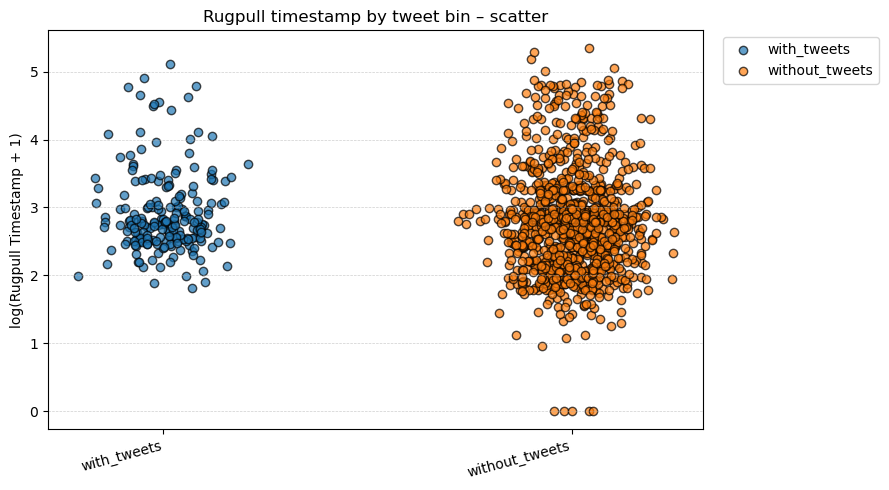

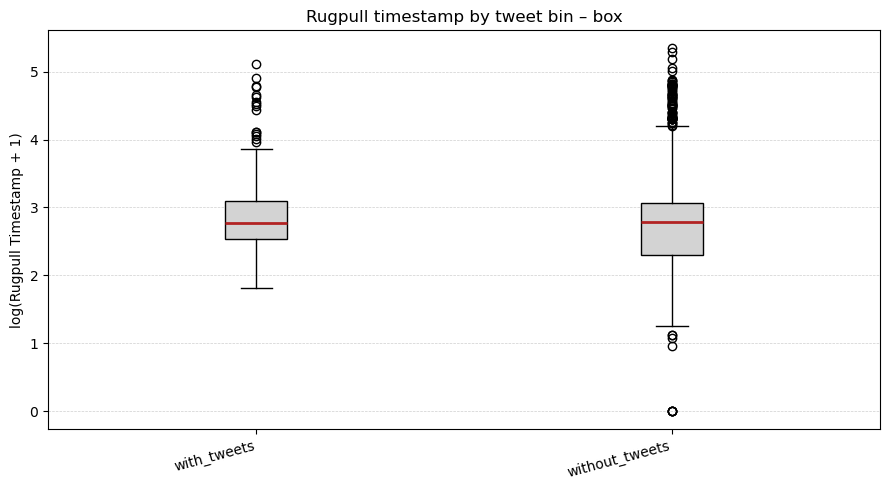

In [9]:
# Let us look at the ATH duration of coins with tweets versus coins without tweets
duration_dict = {
    "with_tweets": [],
    "without_tweets": []
}

for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    # get the ATH duration
    ath_duration = coin_dict["rugpull_time_delta"]
    if ath_duration is None or pd.isna(ath_duration):
        continue
    if ath_duration <= 0:
        ath_duration = 0
    # get the number of tweets
    num_tweets = len(coin_dict["tweets_list"])
    if num_tweets > 0:
        duration_dict["with_tweets"].append(ath_duration)
    else:
        duration_dict["without_tweets"].append(ath_duration)

jitter_scatter(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(Rugpull Timestamp + 1)",
    title="Rugpull timestamp by tweet bin – scatter",
)
group_boxplot(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(Rugpull Timestamp + 1)",
    title="Rugpull timestamp by tweet bin – box",
)

In [10]:
quick_stats(duration_dict, transform=safe_log1p)

with_tweets:  mean=   2.917  median=   2.767  n= 205
without_tweets:  mean=   2.790  median=   2.787  n=1166


Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 1234725.68it/s]


<Axes: title={'center': 'Rugpull timestamp by tweet bin – box'}, ylabel='log(Rugpull Timestamp + 1)'>

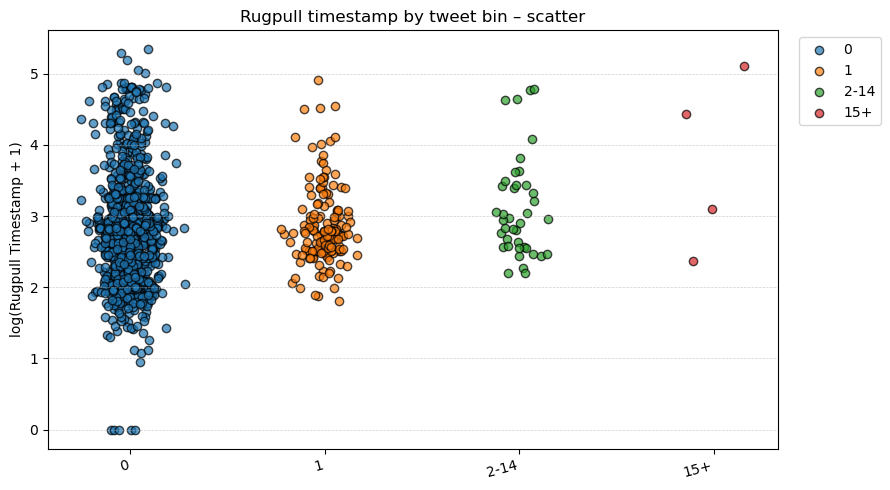

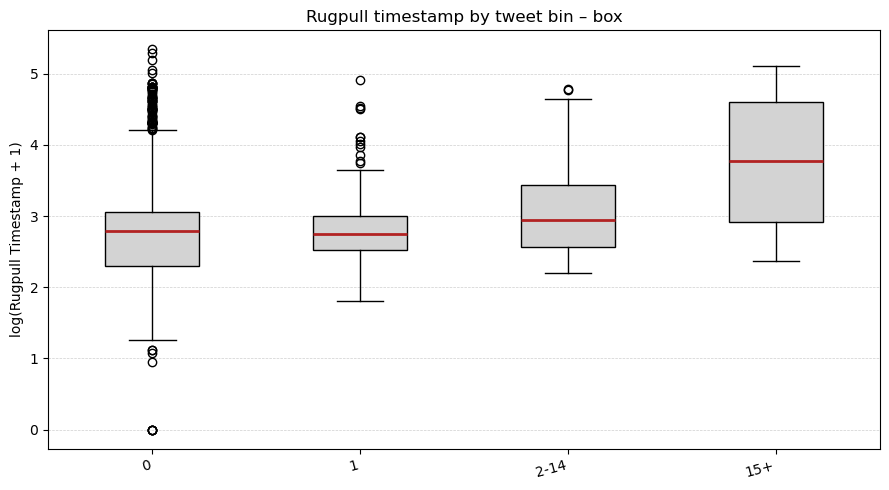

In [11]:
duration_dict = {
    "0": [],
    "1": [],
    "2-14": [],
    "15+": []
}

for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    # get the ATH duration
    ath_duration = coin_dict["rugpull_time_delta"]
    if ath_duration is None or pd.isna(ath_duration):
        continue
    if ath_duration <= 0:
        ath_duration = 0
    # get the number of tweets
    num_tweets = len(coin_dict["tweets_list"])
    if num_tweets == 0:
        duration_dict["0"].append(ath_duration)
    elif num_tweets == 1:
        duration_dict["1"].append(ath_duration)
    elif num_tweets <= 9:
        duration_dict["2-14"].append(ath_duration)
    elif num_tweets >= 15:
        duration_dict["15+"].append(ath_duration)

jitter_scatter(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(Rugpull Timestamp + 1)",
    title="Rugpull timestamp by tweet bin – scatter",
)
group_boxplot(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(Rugpull Timestamp + 1)",
    title="Rugpull timestamp by tweet bin – box",
)

Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 672950.89it/s]

[('TSLvdd1pWpHVjahSpsvCXUbgwsL3JAcvokwaKt1eokM', 374), ('DFWXD4PXb3iM62rLwD89GSBmdiMZufMXmNw6oPs61XQr', 28), ('FEDE3NqKsQz8jHYfNgKJhTbUfKJrkKbxd1mNjwMmtRQC', 26), ('HoiLJuYVyuCSu1ZrHuPywaWRVv9cWeQYuzD1ecZLCgnq', 22), ('Edh4DK6T9acoCoNommJSSibSZtywnADDv55AuhPL7zcJ', 19), ('5B6J8qSdeRtrT41RW8Ceo9sir8i28jZx9wuiJLzjS7z3', 19), ('44hdMF5KCEZoDhevwCS9BdQXJ9Ko2SWyjbYhu7ty67Gc', 16), ('5QxsRmroF3bXEw5KsM6U7of4U5cQ1we1ysvHN869b6hV', 12), ('4iic8FMz1z3G1oRvMhE6xfAvihJj6L85LVXqz8rncBqQ', 11), ('BH3jr1BVghvknryivp1mU2ePxK8EosJc4PRaEcFRML53', 11)]


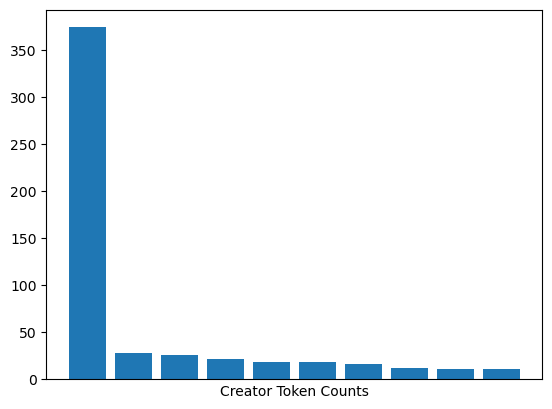

In [38]:
creator_counter = {}

for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    creator = coin_dict["creator"]
    if creator is None or pd.isna(creator):
        continue
    if creator not in creator_counter:
        creator_counter[creator] = 0
    creator_counter[creator] += 1

# get the top 10 creators
top_creators = sorted(creator_counter.items(), key=lambda x: x[1], reverse=True)[:10]
print(top_creators)

# plot the top 10 creators
plt.bar([x[0] for x in top_creators], [x[1] for x in top_creators])
# remove the x-axis labels
# x axis labels are the creators
plt.xlabel("Creator Token Counts")
plt.xticks([])
plt.show()

['TSLvdd1pWpHVjahSpsvCXUbgwsL3JAcvokwaKt1eokM', 'DFWXD4PXb3iM62rLwD89GSBmdiMZufMXmNw6oPs61XQr', 'FEDE3NqKsQz8jHYfNgKJhTbUfKJrkKbxd1mNjwMmtRQC', 'HoiLJuYVyuCSu1ZrHuPywaWRVv9cWeQYuzD1ecZLCgnq', 'Edh4DK6T9acoCoNommJSSibSZtywnADDv55AuhPL7zcJ', '5B6J8qSdeRtrT41RW8Ceo9sir8i28jZx9wuiJLzjS7z3', '44hdMF5KCEZoDhevwCS9BdQXJ9Ko2SWyjbYhu7ty67Gc', '5QxsRmroF3bXEw5KsM6U7of4U5cQ1we1ysvHN869b6hV', '4iic8FMz1z3G1oRvMhE6xfAvihJj6L85LVXqz8rncBqQ', 'BH3jr1BVghvknryivp1mU2ePxK8EosJc4PRaEcFRML53']


Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 882539.46it/s]


<Axes: title={'center': 'ATH duration by creator – box'}, ylabel='log(ATH duration + 1)'>

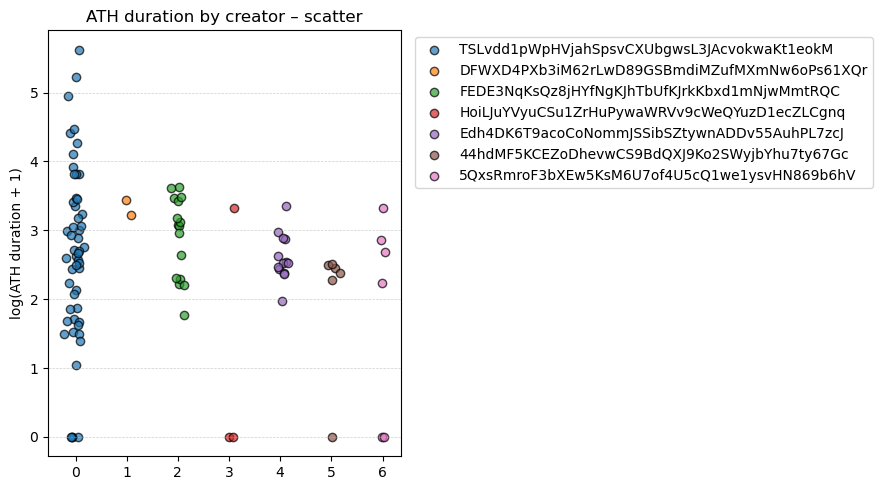

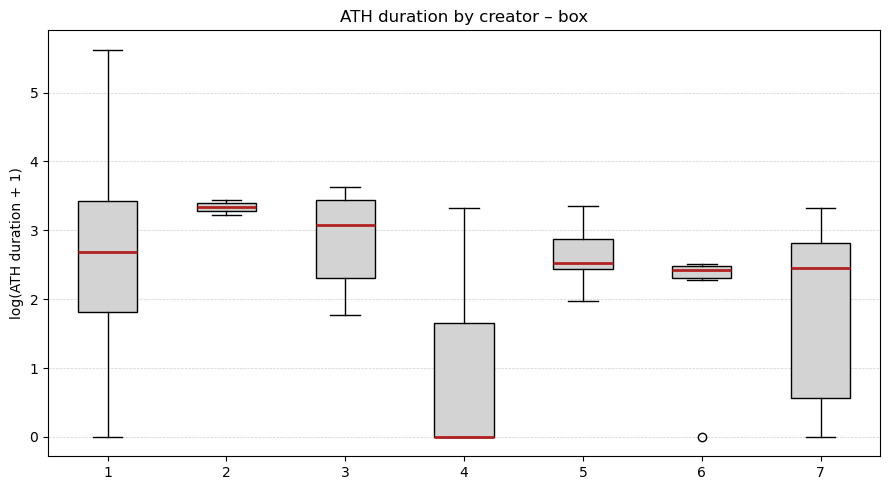

In [40]:
# top creator list 
top_creator_list = [x[0] for x in top_creators]
print(top_creator_list)

duration_dict = {}
for creator in top_creator_list:
    duration_dict[creator] = []

for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    creator = coin_dict["creator"]
    if creator is None or pd.isna(creator):
        continue
    if creator not in duration_dict:
        continue
    ath_duration = coin_dict["ath_time_delta"]
    if ath_duration is None or pd.isna(ath_duration):
        continue
    if ath_duration <= 0:
        ath_duration = 0
    duration_dict[creator].append(ath_duration)

jitter_scatter(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(ATH duration + 1)",
    title="ATH delta by creator – scatter",
    xlabels=False,
)
group_boxplot(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(ATH duration + 1)",
    title="ATH delta by creator – box",
    xlabels=False,
)


In [14]:
quick_stats(duration_dict, transform=safe_log1p)

TSLvdd1pWpHVjahSpsvCXUbgwsL3JAcvokwaKt1eokM:  mean=   2.669  median=   2.685  n=  52
DFWXD4PXb3iM62rLwD89GSBmdiMZufMXmNw6oPs61XQr:  mean=   3.337  median=   3.337  n=   2
FEDE3NqKsQz8jHYfNgKJhTbUfKJrkKbxd1mNjwMmtRQC:  mean=   2.902  median=   3.072  n=  16
HoiLJuYVyuCSu1ZrHuPywaWRVv9cWeQYuzD1ecZLCgnq:  mean=   1.107  median=   0.000  n=   3
Edh4DK6T9acoCoNommJSSibSZtywnADDv55AuhPL7zcJ:  mean=   2.609  median=   2.529  n=  13
5B6J8qSdeRtrT41RW8Ceo9sir8i28jZx9wuiJLzjS7z3:  (no data)
44hdMF5KCEZoDhevwCS9BdQXJ9Ko2SWyjbYhu7ty67Gc:  mean=   2.020  median=   2.416  n=   6
5QxsRmroF3bXEw5KsM6U7of4U5cQ1we1ysvHN869b6hV:  mean=   1.848  median=   2.455  n=   6
4iic8FMz1z3G1oRvMhE6xfAvihJj6L85LVXqz8rncBqQ:  (no data)
BH3jr1BVghvknryivp1mU2ePxK8EosJc4PRaEcFRML53:  (no data)


['TSLvdd1pWpHVjahSpsvCXUbgwsL3JAcvokwaKt1eokM', 'DFWXD4PXb3iM62rLwD89GSBmdiMZufMXmNw6oPs61XQr', 'FEDE3NqKsQz8jHYfNgKJhTbUfKJrkKbxd1mNjwMmtRQC', 'HoiLJuYVyuCSu1ZrHuPywaWRVv9cWeQYuzD1ecZLCgnq', 'Edh4DK6T9acoCoNommJSSibSZtywnADDv55AuhPL7zcJ', '5B6J8qSdeRtrT41RW8Ceo9sir8i28jZx9wuiJLzjS7z3', '44hdMF5KCEZoDhevwCS9BdQXJ9Ko2SWyjbYhu7ty67Gc', '5QxsRmroF3bXEw5KsM6U7of4U5cQ1we1ysvHN869b6hV', '4iic8FMz1z3G1oRvMhE6xfAvihJj6L85LVXqz8rncBqQ', 'BH3jr1BVghvknryivp1mU2ePxK8EosJc4PRaEcFRML53']


Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 958075.63it/s]


<Axes: title={'center': 'Rugpull timestamp by creator – box'}, ylabel='log(Rugpull Timestamp + 1)'>

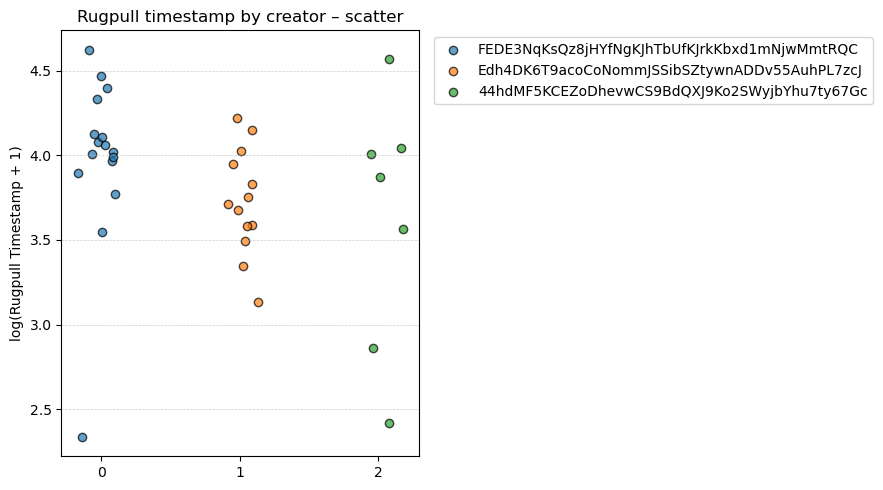

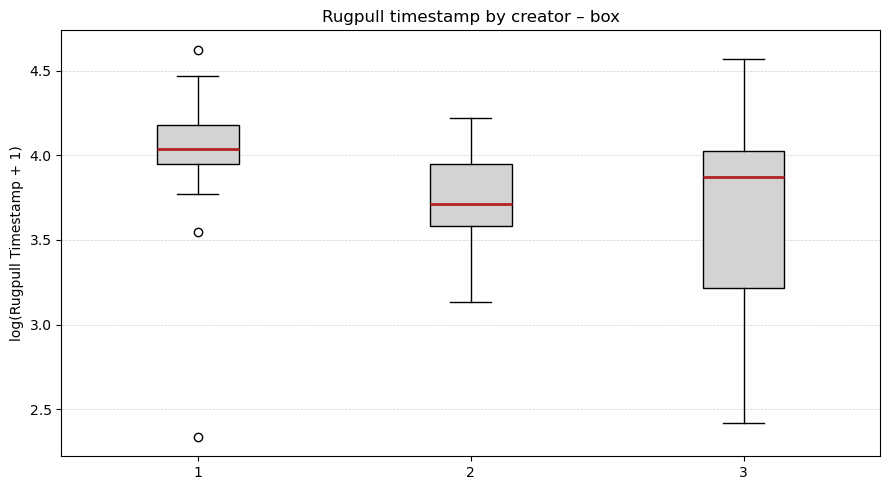

In [15]:
# top creator list 
top_creator_list = [x[0] for x in top_creators]
print(top_creator_list)

duration_dict = {}
for creator in top_creator_list:
    duration_dict[creator] = []

for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    creator = coin_dict["creator"]
    if creator is None or pd.isna(creator):
        continue
    if creator not in duration_dict:
        continue
    ath_duration = coin_dict["rugpull_time_delta"]
    if ath_duration is None or pd.isna(ath_duration):
        continue
    if ath_duration <= 0:
        ath_duration = 0
    duration_dict[creator].append(ath_duration)

jitter_scatter(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(Rugpull Timestamp + 1)",
    title="Rugpull timestamp by creator – scatter",
    xlabels=False,
)
group_boxplot(
    duration_dict,
    transform=safe_log1p,
    ylabel="log(Rugpull Timestamp + 1)",
    title="Rugpull timestamp by creator – box",
    xlabels=False,
)


In [16]:
quick_stats(duration_dict, transform=safe_log1p)

TSLvdd1pWpHVjahSpsvCXUbgwsL3JAcvokwaKt1eokM:  (no data)
DFWXD4PXb3iM62rLwD89GSBmdiMZufMXmNw6oPs61XQr:  (no data)
FEDE3NqKsQz8jHYfNgKJhTbUfKJrkKbxd1mNjwMmtRQC:  mean=   3.984  median=   4.040  n=  16
HoiLJuYVyuCSu1ZrHuPywaWRVv9cWeQYuzD1ecZLCgnq:  (no data)
Edh4DK6T9acoCoNommJSSibSZtywnADDv55AuhPL7zcJ:  mean=   3.728  median=   3.712  n=  13
5B6J8qSdeRtrT41RW8Ceo9sir8i28jZx9wuiJLzjS7z3:  (no data)
44hdMF5KCEZoDhevwCS9BdQXJ9Ko2SWyjbYhu7ty67Gc:  mean=   3.621  median=   3.875  n=   7
5QxsRmroF3bXEw5KsM6U7of4U5cQ1we1ysvHN869b6hV:  (no data)
4iic8FMz1z3G1oRvMhE6xfAvihJj6L85LVXqz8rncBqQ:  (no data)
BH3jr1BVghvknryivp1mU2ePxK8EosJc4PRaEcFRML53:  (no data)


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections.abc import Sequence, Iterable, Callable
from typing import Any


def paired_scatter(
    X: Sequence[Iterable[Any]],
    Y: Sequence[Iterable[Any]],
    *,
    x_transform: Callable[[np.ndarray], np.ndarray] = None,
    y_transform: Callable[[np.ndarray], np.ndarray] = None,
    ax: plt.Axes = None,
    title: str = "",
    xlabel: str = "X",
    ylabel: str = "Y",
    alpha: float = 0.6,
    marker_size: float = 40,
    show_corr: bool = True,
    show_regline: bool = True,
    scatter_kwargs: dict[str, Any] = None,
    regline_kwargs: dict[str, Any] = None,
) -> plt.Axes:
    """
    Flatten & plot paired (X, Y) lists; optionally add correlation stats and
    a best‑fit regression line. Returns the `matplotlib.Axes` used.

    Parameters
    ----------
    X, Y : Sequence[list‑like]
        Must be **aligned**; each X[i] and Y[i] are sequences of equal length.
    x_transform / y_transform : callable | None
        Optional transformation applied after flattening (e.g. ``np.log1p``).
    show_corr : bool
        Adds Pearson/Spearman r to the title.
    show_regline : bool
        Draws a least‑squares regression line (after transforms).
    scatter_kwargs / regline_kwargs : dict | None
        Extra keyword arguments forwarded to ``Axes.scatter`` and
        ``Axes.plot`` for custom styling.
    """

    if scatter_kwargs is None:
        scatter_kwargs = {}

    if regline_kwargs is None:
        regline_kwargs = {"linewidth": 1.5, "linestyle": "--"}

    # --- helper to handle both already‑flat and nested inputs -------------
    def _prepare_xy(x_raw, y_raw):
        x_arr = np.asarray(x_raw, dtype=float)
        y_arr = np.asarray(y_raw, dtype=float)
        mask = np.isfinite(x_arr) & np.isfinite(y_arr)
        x_arr, y_arr = x_arr[mask], y_arr[mask]
        if x_transform:
            x_arr = x_transform(x_arr)
        if y_transform:
            y_arr = y_transform(y_arr)
        return x_arr, y_arr

    # ---------------------------------------------------------------------
    if X and not hasattr(X[0], "__len__"):
        # Input is already flat
        x, y = _prepare_xy(X, Y)
    else:
        # Flatten nested lists, enforcing alignment per row
        flat_x, flat_y = [], []
        for xi, yi in zip(X, Y):
            if len(xi) != len(yi):
                raise ValueError("Mismatch in lengths for a pair of X/Y sub‑lists.")
            flat_x.extend(xi)
            flat_y.extend(yi)
        x, y = _prepare_xy(flat_x, flat_y)

    # Ensure we have something to plot
    if x.size == 0:
        raise ValueError("No valid (finite) X–Y pairs to plot after filtering.")

    # ---------------- plotting ------------------------------------------
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(x, y, s=marker_size, alpha=alpha, **scatter_kwargs)

    # ---------- regression line -----------------------------------------
    if show_regline and x.size > 1:
        # Ordinary least squares y = m*x + b
        slope, intercept, _, _, _ = stats.linregress(x, y)
        xp = np.array([x.min(), x.max()])
        yp = slope * xp + intercept
        # Default to using alpha from scatter for consistency unless overridden
        if "alpha" not in regline_kwargs:
            regline_kwargs["alpha"] = alpha
        ax.plot(xp, yp, **regline_kwargs)

    # ---------- labels & title ------------------------------------------
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    if title:
        base_title = title
    else:
        base_title = f"{xlabel} vs. {ylabel} scatter"

    if show_corr and x.size > 1:
        pear_r, _ = stats.pearsonr(x, y)
        spear_r, _ = stats.spearmanr(x, y)
        ax.set_title(
            f"{base_title}\nPearson r = {pear_r:.3f}   •   Spearman ρ = {spear_r:.3f}")
    else:
        ax.set_title(base_title)

    plt.tight_layout()
    return ax


/Users/mahdikhemakhem/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections.abc import Sequence, Iterable, Callable
from typing import Any


def paired_scatter(
    X: Sequence[Iterable[Any]],
    Y: Sequence[Iterable[Any]],
    *,
    x_transform: Callable[[np.ndarray], np.ndarray]  = None,
    y_transform: Callable[[np.ndarray], np.ndarray]  = None,
    ax: plt.Axes = None,
    title: str = "",
    xlabel: str = "X",
    ylabel: str = "Y",
    alpha: float = 0.6,
    marker_size: float = 40,
    show_corr: bool = True,
    show_pvals: bool = True,
    show_regline: bool = True,
    scatter_kwargs: dict[str, Any] = None,
    regline_kwargs: dict[str, Any] = None,
) -> plt.Axes:
    """Plot paired *(X, Y)* observations, optionally adding a regression line and
    correlation statistics.

    Parameters
    ----------
    X, Y : sequence of list-like
        Aligned containers – every *X[i]* must be the same length as *Y[i]*. If
        the inputs are already flat 1-D lists/arrays, that is accepted as well.
    x_transform / y_transform : callable, optional
        Function applied element-wise *after* flattening (e.g. ``np.log1p``).
    show_corr : bool, default ``True``
        Display Pearson *r* and Spearman *ρ* in the title.
    show_pvals : bool, default ``True``
        If ``show_corr`` is enabled, also show two-tailed *p*-values.
    show_regline : bool, default ``True``
        Draw an ordinary-least-squares fit line (after any transforms).
    scatter_kwargs / regline_kwargs : dict, optional
        Extra styling passed to ``Axes.scatter`` and ``Axes.plot``.
    """

    # ---------------- housekeeping ----------------------------------------
    if scatter_kwargs is None:
        scatter_kwargs = {}
    if regline_kwargs is None:
        regline_kwargs = {"linewidth": 1.6, "linestyle": "--"}

    # ----- helper to prepare x / y ---------------------------------------
    def _prep(x_raw, y_raw):
        x_arr = np.asarray(x_raw, dtype=float)
        y_arr = np.asarray(y_raw, dtype=float)
        mask = np.isfinite(x_arr) & np.isfinite(y_arr)
        x_arr, y_arr = x_arr[mask], y_arr[mask]
        if x_transform is not None:
            x_arr = x_transform(x_arr)
        if y_transform is not None:
            y_arr = y_transform(y_arr)
        return x_arr, y_arr

    # ----- flatten if needed ---------------------------------------------
    if X and not hasattr(X[0], "__len__"):
        x, y = _prep(X, Y)
    else:
        flat_x, flat_y = [], []
        for xi, yi in zip(X, Y):
            if len(xi) != len(yi):
                raise ValueError("Mismatch in lengths for a pair of X/Y sub-lists.")
            flat_x.extend(xi)
            flat_y.extend(yi)
        x, y = _prep(flat_x, flat_y)

    if x.size == 0:
        raise ValueError("No valid (finite) X–Y pairs to plot.")

    # ---------------- figure / axis --------------------------------------
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(x, y, s=marker_size, alpha=alpha, **scatter_kwargs)

    # ---------------- regression line ------------------------------------
    if show_regline and x.size > 1:
        slope, intercept, _, _, _ = stats.linregress(x, y)
        xp = np.array([x.min(), x.max()])
        yp = slope * xp + intercept
        if "alpha" not in regline_kwargs:
            regline_kwargs["alpha"] = alpha
        ax.plot(xp, yp, **regline_kwargs)

    # ---------------- labels & grid --------------------------------------
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    # ---------------- title / statistics ---------------------------------
    base_title = title or f"{xlabel} vs. {ylabel} scatter"

    if show_corr and x.size > 1:
        pear_r, pear_p = stats.pearsonr(x, y)
        spear_r, spear_p = stats.spearmanr(x, y)
        stats_txt = (
            f"Pearson r = {pear_r:.3f}"
            + (f" (p = {pear_p:.3g})" if show_pvals else "")
            + "   •   "
            + f"Spearman ρ = {spear_r:.3f}"
            + (f" (p = {spear_p:.3g})" if show_pvals else "")
        )
        ax.set_title(f"{base_title}\n{stats_txt}")
    else:
        ax.set_title(base_title)

    plt.tight_layout()
    return ax

Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 862649.39it/s]

426 426


<Axes: title={'center': 'Engagement vs. ATH duration\nPearson r = -0.141 (p = 0.00352)   •   Spearman ρ = -0.071 (p = 0.141)'}, xlabel='Tweet engagement score', ylabel='log(ATH duration + 1)'>

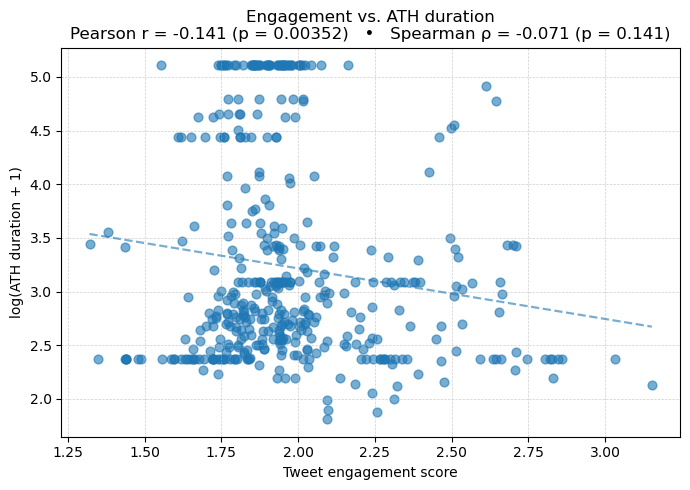

In [44]:
X = []
Y = []
X_avg = []
Y_avg = []
for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    engagement_list = coin_dict["engagement_list"]
    if len(engagement_list) == 0:
        continue
    ath_duration = coin_dict["rugpull_time_delta"]
    if ath_duration is None or pd.isna(ath_duration):
        continue
    if ath_duration <= 0:
        ath_duration = 0
    # create an array of engagement_list length
    ath_list = [ath_duration] * len(engagement_list)
    average_engagement = np.mean(engagement_list)

    X.extend(engagement_list)
    Y.extend(ath_list)
    X_avg.append(average_engagement)
    Y_avg.append(ath_duration)

print(len(X), len(Y))

paired_scatter(
    X, Y,
    x_transform=None,          # maybe np.log1p if you prefer
    y_transform=safe_log1p,    # log-scale ATH duration (like before)
    xlabel="Tweet engagement score",
    ylabel="log(ATH duration + 1)",
    title="Engagement vs. ATH duration",
)



<Axes: title={'center': 'Engagement vs. ATH duration\nPearson r = -0.056 (p = 0.425)   •   Spearman ρ = -0.145 (p = 0.038)'}, xlabel='Tweet engagement score', ylabel='log(ATH duration + 1)'>

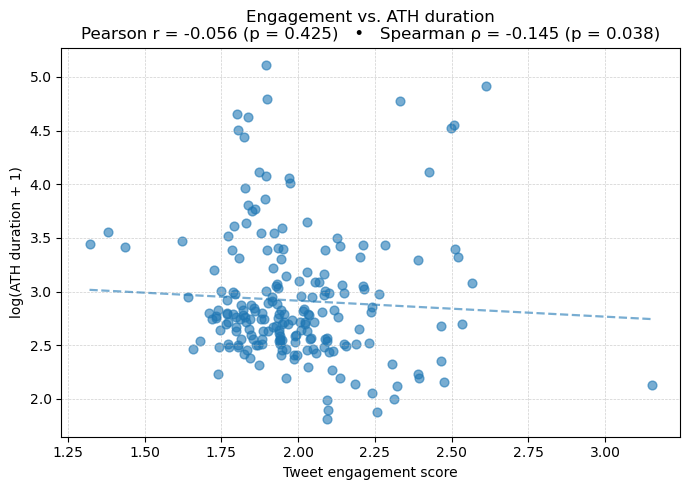

In [45]:
paired_scatter(
    X_avg, Y_avg,
    x_transform=None,          # maybe np.log1p if you prefer
    y_transform=safe_log1p,    # log-scale ATH duration (like before)
    xlabel="Tweet engagement score",
    ylabel="log(ATH duration + 1)",
    title="Engagement vs. ATH duration",
)

Processing coins: 100%|██████████| 4134/4134 [00:00<00:00, 746898.67it/s]

628 628


<Axes: title={'center': 'Sentiment vs. ATH price gain\nPearson r = -0.086 (p = 0.0317)   •   Spearman ρ = -0.064 (p = 0.111)'}, xlabel='Tweet sentiment score', ylabel='log(ATH price gain + 1)'>

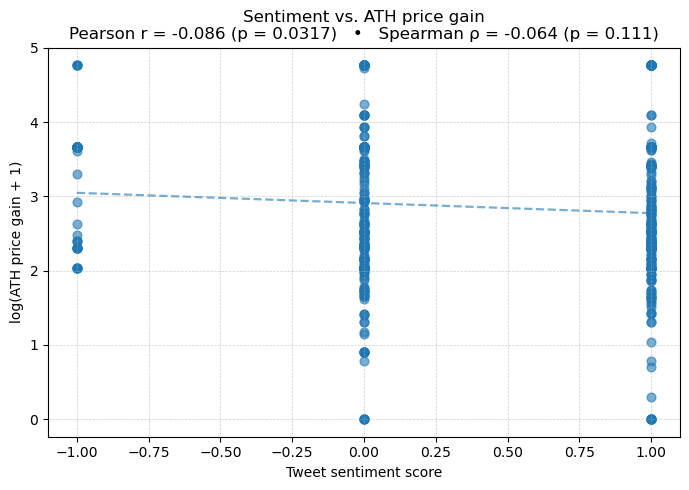

In [66]:
X = []
Y = []
X_avg = []
Y_avg = []
for coin, coin_dict in tqdm(coin_data.items(), total=len(coin_data), desc="Processing coins"):
    sentiment_list = coin_dict["sentiment_list"]
    if len(sentiment_list) == 0:
        continue
    engagement_list = []
    for label in sentiment_list:
        if label == "positive":
            engagement_list.append(1)
        elif label == "negative":
            engagement_list.append(-1)
        else:
            engagement_list.append(0)
    ath_duration = coin_dict["ath_time_delta"]
    if ath_duration is None or pd.isna(ath_duration):
        continue
    if ath_duration <= 0:
        ath_duration = 0
    # create an array of engagement_list length
    ath_list = [ath_duration] * len(engagement_list)
    average_engagement = np.mean(engagement_list)

    X.extend(engagement_list)
    Y.extend(ath_list)
    X_avg.append(average_engagement)
    Y_avg.append(ath_duration)

print(len(X), len(Y))

paired_scatter(
    X, Y,
    x_transform=None,          # maybe np.log1p if you prefer
    y_transform=safe_log1p,    # log-scale ATH duration (like before)
    xlabel="Tweet sentiment score",
    ylabel="log(ATH price gain + 1)",
    title="Sentiment vs. ATH price gain",
)

<Axes: title={'center': 'Sentiment vs. ATH price gain\nPearson r = -0.107 (p = 0.116)   •   Spearman ρ = -0.093 (p = 0.172)'}, xlabel='Tweet sentiment score', ylabel='log(ATH price gain + 1)'>

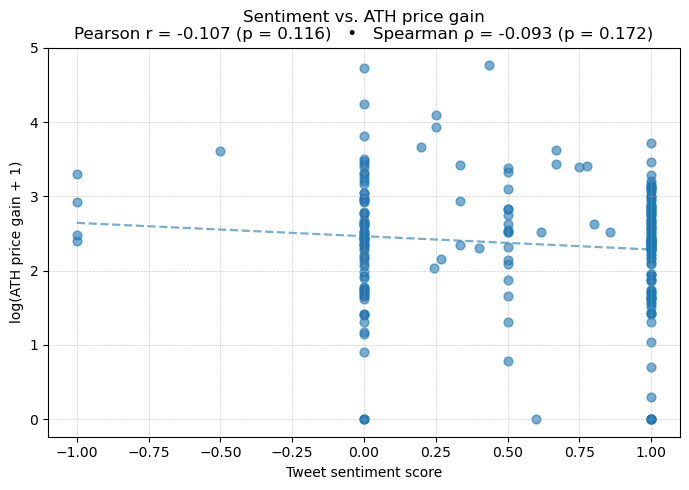

In [67]:
paired_scatter(
    X_avg, Y_avg,
    x_transform=None,          # maybe np.log1p if you prefer
    y_transform=safe_log1p,    # log-scale ATH duration (like before)
    xlabel="Tweet sentiment score",
    ylabel="log(ATH price gain + 1)",
    title="Sentiment vs. ATH price gain",
)